In [2]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly
import seaborn as sns

def compare(reference, results, column_to):
    closest = pd.concat([x.idxmin() for x in distances(reference,results,column_to)]).reset_index(drop=True)
    best_clustering = pd.concat([x['IOU_GT'] for x in results.values()],axis=1).T.reset_index(drop=True).T.idxmax(axis=1)
    best_ouratio = pd.concat([abs(x['ouratio']-1) for x in results.values()],axis=1).T.reset_index(drop=True).T.idxmin(axis=1)
    best_ratio = pd.concat([np.sqrt(x[column_to]*x.Pred) for x in results.values()],axis=1).T.reset_index(drop=True).T.idxmax(axis=1)
    pareto_distance = pd.concat([x.idxmin() for x in distances_pareto(reference,results,column_to)]).reset_index(drop=True)
    stacked = pd.concat([closest,best_clustering,best_ouratio,best_ratio,pareto_distance],axis=1)
    stacked.columns = ['closest','eval','ouratio','ratio','pareto']
    return stacked

def distances_pareto(reference, results, col_name):
    max_pred = pd.concat([x.Pred for x in results.values()],axis=1).max(axis=1)
    max_col = pd.concat([x[col_name] for x in results.values()],axis=1).max(axis=1)
    res = []
    for uid,da in reference.groupby(level=0):
        res.append(pd.DataFrame(np.sqrt((x.loc[uid].Pred - max_pred.loc[uid]) ** 2 + (x.loc[uid][col_name] - max_col.loc[uid]) ** 2) for x in results.values()))
    return res


def distances(reference, results, col_name):
    res = []
    for uid,da in reference.groupby(level=0):
        res.append(pd.DataFrame(np.sqrt((x.loc[uid].Pred - reference.loc[uid].Pred) ** 2 + (x.loc[uid][col_name] - reference.loc[uid][col_name]) ** 2) for x in results.values()))
    return res

In [3]:

# Path to the .pkl file
res = 'results_infostop.pkl'

# Load the dictionary from the .pkl file
with open(res, 'rb') as file:
    results = pickle.load(file)

In [4]:

# Path to the .pkl file
ref = 'reference_infostop.pkl'

# Load the dictionary from the .pkl file
with open(ref, 'rb') as file:
    reference = pickle.load(file)

In [5]:
[x for x in results.values()][3]['PredH']

KeyError: 'PredH'

In [ ]:
reference[]

In [ ]:
comparison = compare(reference,results,"clusT_total")

In [ ]:
comparison

In [6]:
reference.Uq.sum()

437

In [7]:
reference

,Pred,Real,PredP,RealP,PredH,RealH,clus_points,clust_stops,clusT_total,clusT_visits,Uq,Records,Stops,UqH,RecordsH,StopsH,Trans,SG,PredHC,RealHC
0,0.633542,2.504599,0.982475,0.203048,0.976087,0.264457,0.131380,0.146275,0.125642,0.124097,20,94,94,19,2699,89,0.456236,2.287283,0.981334,0.211716
1,0.532336,3.594664,0.998204,0.028994,0.979623,0.256734,0.144632,0.164103,0.180378,0.182637,48,115,115,47,2694,103,0.627577,2.651618,0.983400,0.213593
2,0.570851,2.926749,0.993695,0.084059,0.988896,0.138251,0.102816,0.106792,0.081176,0.079852,24,74,74,23,2833,70,0.222912,1.985166,0.991671,0.106646
3,0.523683,2.427333,0.995098,0.060201,0.990075,0.111755,0.015788,0.015817,0.025504,0.024821,9,21,21,9,2821,19,0.175950,1.602258,0.995866,0.051086
4,0.620773,2.568424,0.982932,0.198411,0.977580,0.250059,0.155288,0.169024,0.182908,0.184479,20,71,71,19,2731,70,0.399697,2.656631,0.981977,0.205344
6,0.587996,2.727705,0.977883,0.248754,0.984771,0.178428,0.072208,0.073796,0.038941,0.037794,20,67,67,19,2829,61,0.611381,1.704957,0.991028,0.111306
7,0.580904,2.309532,0.990648,0.107530,0.992730,0.086248,0.032603,0.032944,0.028972,0.026130,10,29,29,10,2797,28,0.308849,1.612776,0.993613,0.076000
8,0.580403,3.285631,0.962630,0.436514,0.955526,0.506686,0.187731,0.207894,0.141383,0.141001,46,178,178,45,2628,161,1.401914,2.407137,0.963869,0.421522
9,0.752283,1.912314,0.980519,0.226644,0.974019,0.291343,0.178823,0.193455,0.202489,0.205941,23,86,86,23,2716,84,0.433165,2.808714,0.982903,0.201056
11,0.643284,2.530676,0.984462,0.185886,0.977646,0.251071,0.124788,0.127805,0.176940,0.177909,23,82,82,20,2727,77,0.505151,2.614631,0.980667,0.219807


In [114]:
results

{"[50, 3, 30, '3T']":         Pred      Real     PredP     RealP     PredH     RealH  clus_points  \
 0   0.635756  2.434985  0.979764  0.227146  0.905603  0.789386     0.102082   
 1   0.443944  4.635634  0.997862  0.036084  0.941420  0.617280     0.153904   
 2   0.581073  3.036577  0.992750  0.097872  0.965203  0.357098     0.097584   
 3   0.483854  2.635390  0.991103  0.102949  0.980298  0.198868     0.016633   
 4   0.612209  2.478416  0.979054  0.230504  0.909422  0.800707     0.137316   
 6   0.637746  2.393555  0.968946  0.326580  0.968275  0.316699     0.052062   
 7   0.512666  2.461538  0.990195  0.110576  0.978288  0.211905     0.023080   
 8   0.556552  3.166705  0.970723  0.335801  0.885203  1.047320     0.109785   
 9   0.735194  2.014798  0.975298  0.278820  0.875965  1.058068     0.156243   
 11  0.615478  2.594595  0.978609  0.241631  0.921356  0.696807     0.105682   
 12  0.688217  2.219653  0.979062  0.237169  0.922001  0.692061     0.094914   
 13  0.713424  1.60

In [8]:
xval = 'Pred'
yval = 'Real'

# Dictionary to collect results per person
summary_results = {}

for person in reference.index:
    # Extract values
    x_values = [x.loc[person][xval] for x in results.values()]
    y_values = [x.loc[person][yval] for x in results.values()]
    z_values = [(2 * x.loc[person]['IOU_GT'] * x.loc[person]['IOU_PRED']) / 
                (x.loc[person]['IOU_GT'] + x.loc[person]['IOU_PRED']) for x in results.values()]
    
    annot = list(results.keys())  # Parameter keys

    # Combine values with annotations
    data = np.array(list(zip(x_values, y_values, z_values, annot)))

    # Sort by x descending, then y descending (maximizing both)
    sorted_indices = np.lexsort((-data[:, 1].astype(float), -data[:, 0].astype(float)))
    data = data[sorted_indices]

    # Find Pareto frontier
    pareto_annot = []
    pareto_frontier = []
    for point in data:
        if not pareto_frontier or float(point[1]) > float(pareto_frontier[-1][1]):  # Maximizing y
            pareto_frontier.append(point)
            pareto_annot.append(point[3])  # Store param key
    
    # Compute IOU F1-score
    iou_scores = {k: (2 * x.loc[person]['IOU_GT'] * x.loc[person]['IOU_PRED']) / 
                     (x.loc[person]['IOU_GT'] + x.loc[person]['IOU_PRED']) for k, x in results.items()}
    df_iou = pd.DataFrame.from_dict(iou_scores, orient='index', columns=['IOU_F1'])
    
    # Separate in-pareto and out-of-pareto
    df_iou['in_pareto'] = df_iou.index.isin(pareto_annot)

    # Calculate statistics
    in_pareto_stats = df_iou[df_iou['in_pareto']]['IOU_F1'].agg(['mean', 'std', 'max', 'min'])
    out_pareto_stats = df_iou[~df_iou['in_pareto']]['IOU_F1'].agg(['mean', 'std', 'max', 'min'])

    # Store results
    summary_results[person] = {
        'in_pareto_mean': in_pareto_stats['mean'],
        'in_pareto_std': in_pareto_stats['std'],
        'in_pareto_max': in_pareto_stats['max'],
        'in_pareto_min': in_pareto_stats['min'],
        'out_pareto_mean': out_pareto_stats['mean'],
        'out_pareto_std': out_pareto_stats['std'],
        'out_pareto_max': out_pareto_stats['max'],
        'out_pareto_min': out_pareto_stats['min'],
        'num_in_pareto': df_iou['in_pareto'].sum(),
        'num_out_pareto': (~df_iou['in_pareto']).sum(),
        'pareto_mean_up': in_pareto_stats['mean'] - out_pareto_stats['mean'],
        'pareto_max_up': in_pareto_stats['max'] - out_pareto_stats['max'],
        'pareto_min_up': in_pareto_stats['min'] - out_pareto_stats['min'],
    }

# Convert to DataFrame for easy comparison
summary_df = pd.DataFrame.from_dict(summary_results, orient='index')

# Display summary DataFrame
summary_df

C:\Users\kamil\AppData\Local\Temp\ipykernel_15852\384442258.py:17: RuntimeWarning: invalid value encountered in cast
  data = np.array(list(zip(x_values, y_values, z_values, annot)))
C:\Users\kamil\AppData\Local\Temp\ipykernel_15852\384442258.py:17: RuntimeWarning: invalid value encountered in cast
  data = np.array(list(zip(x_values, y_values, z_values, annot)))


,in_pareto_mean,in_pareto_std,in_pareto_max,in_pareto_min,out_pareto_mean,out_pareto_std,out_pareto_max,out_pareto_min,num_in_pareto,num_out_pareto,pareto_mean_up,pareto_max_up,pareto_min_up
0,0.860923,0.035617,0.916222,0.800016,0.849998,0.064791,0.965998,0.655439,21,189,0.010925,-0.049776,0.144577
1,0.811116,0.093913,0.937954,0.506227,0.654056,0.159675,0.939438,0.309265,28,182,0.157060,-0.001484,0.196962
2,0.915779,0.060616,0.987102,0.777028,0.893263,0.070930,0.985335,0.744456,34,176,0.022515,0.001767,0.032572
3,0.429382,0.087780,0.571416,0.306935,0.405655,0.158656,0.690835,0.189055,6,204,0.023727,-0.119419,0.117880
4,0.791397,0.105460,0.941880,0.553258,0.744225,0.082166,0.929958,0.542876,23,187,0.047172,0.011922,0.010381
6,0.732611,0.120323,0.884519,0.412164,0.556974,0.254170,0.958083,0.138825,26,184,0.175637,-0.073564,0.273339
7,0.868741,0.046201,0.938454,0.748969,0.658421,0.155457,0.921580,0.406101,15,195,0.210320,0.016873,0.342868
8,0.802225,0.058090,0.874872,0.650645,0.652560,0.140973,0.891223,0.303697,15,195,0.149666,-0.016351,0.346948
9,0.870925,0.045784,0.957421,0.765960,0.836025,0.055948,0.957618,0.707182,32,178,0.034901,-0.000197,0.058778
11,0.822964,0.085867,0.914697,0.636841,0.790015,0.098623,0.916833,0.554832,31,179,0.032948,-0.002137,0.082009


In [10]:
top_pareto_summary = {}
xval = "PredP"
yval = "RealP"
for person in reference.index:
    # Extract values
    x_values = [x.loc[person][xval] for x in results.values()]
    y_values = [x.loc[person][yval] for x in results.values()]
    iou_scores = [(2 * x.loc[person]['IOU_GT'] * x.loc[person]['IOU_PRED']) / 
                  (x.loc[person]['IOU_GT'] + x.loc[person]['IOU_PRED']) for x in results.values()]
    annot = list(results.keys())

    # Combine values
    data = pd.DataFrame({
        'x': x_values,
        'y': y_values,
        'iou': iou_scores,
        'annot': annot
    })

    # Sort for Pareto detection
    data_sorted = data.sort_values(['x', 'y'], ascending=[False, False]).reset_index(drop=True)

    # Find Pareto solutions
    pareto_flags = []
    current_best_y = -np.inf
    for idx, row in data_sorted.iterrows():
        if row['y'] > current_best_y:
            pareto_flags.append(True)
            current_best_y = row['y']
        else:
            pareto_flags.append(False)
    data_sorted['pareto'] = pareto_flags

    # Filter Pareto solutions
    pareto_df = data_sorted[data_sorted['pareto']]

    ## ---- New Part ----
    # Rank Pareto by IOU F1
    pareto_df = pareto_df.sort_values('iou', ascending=False).reset_index(drop=True)

    # Take Top-3
    top3 = pareto_df.head(5)

    # Summary stats
    top_pareto_summary[person] = {
        'top1_iou': top3.iloc[0]['iou'],
        'top3_median_iou': top3['iou'].median(),
        'pareto_max_iou': pareto_df['iou'].max(),
        'pareto_median_iou': pareto_df['iou'].mean(),
        'non_pareto_median_iou': data_sorted[~data_sorted['pareto']]['iou'].mean(),
        'non_pareto_max_iou': data_sorted[~data_sorted['pareto']]['iou'].max(),
        'complexity_top1': top3.iloc[0]['y'],
        'complexity_top3_median': top3['y'].median(),
        'distance_to_best': data_sorted['iou'].max() - top3['iou'].max()
    }

# Convert to DataFrame
top_pareto_df = pd.DataFrame.from_dict(top_pareto_summary, orient='index')

print((top_pareto_df['pareto_median_iou'] - top_pareto_df['non_pareto_median_iou']).mean())
top_pareto_df

0.01976196674134722


,top1_iou,top3_median_iou,pareto_max_iou,pareto_median_iou,non_pareto_median_iou,non_pareto_max_iou,complexity_top1,complexity_top3_median,distance_to_best
0,0.968286,0.937318,0.968286,0.911207,0.897873,0.975162,0.188111,0.188111,0.006877
1,0.959518,0.958691,0.959518,0.916569,0.819424,0.967650,0.036023,0.036724,0.008133
2,0.990221,0.989562,0.990221,0.922610,0.898996,0.996626,0.097872,0.078040,0.006406
3,0.886406,0.886392,0.886406,0.766131,0.769504,0.886406,0.046525,0.065599,0.000000
4,0.969376,0.951213,0.969376,0.944327,0.937190,0.981283,0.184723,0.191407,0.011907
6,0.928567,0.884895,0.928567,0.720728,0.633802,0.973675,0.220411,0.229247,0.045108
7,0.938602,0.874138,0.938602,0.793883,0.746799,0.953487,0.108071,0.107736,0.014885
8,0.889854,0.869835,0.889854,0.733956,0.668381,0.870797,0.502893,0.451371,0.000000
9,0.974439,0.972444,0.974439,0.965314,0.925279,0.982352,0.280186,0.256338,0.007912
11,0.962461,0.925261,0.962461,0.862237,0.903925,0.962522,0.176284,0.184594,0.000061


In [11]:
top_pareto_df.median(axis=0)

top1_iou                  0.965373
top3_median_iou           0.940205
pareto_max_iou            0.965373
pareto_median_iou         0.856743
non_pareto_median_iou     0.893294
non_pareto_max_iou        0.974419
complexity_top1           0.180504
complexity_top3_median    0.186352
distance_to_best          0.006641
dtype: float64

In [12]:
def is_pareto_efficient(costs):
    """
    Find the Pareto-efficient points in a 3D objective space.
    Args:
        costs (np.ndarray): Array of shape (n_points, 3) with each row as (x, y, z)
    Returns:
        np.ndarray: Boolean mask of Pareto-efficient points.
    """
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs[is_efficient] > c, axis=1) | np.all(costs[is_efficient] == c, axis=1)
            is_efficient[i] = True  # Keep self
    return is_efficient


In [29]:
top_pareto_summary = {}
xval = "Pred"
yval = "Real"
zval = "Stops"

for person in reference.index:
    x_values = [x.loc[person][xval] for x in results.values()]
    y_values = [x.loc[person][yval] for x in results.values()]
    z_values = [x.loc[person][zval] for x in results.values()]
    iou_scores = [(2 * x.loc[person]['IOU_GT'] * x.loc[person]['IOU_PRED']) /
                  (x.loc[person]['IOU_GT'] + x.loc[person]['IOU_PRED']) for x in results.values()]
    annot = list(results.keys())

    data = pd.DataFrame({
        'x': x_values,
        'y': y_values,
        'z': z_values,
        'iou': iou_scores,
        'annot': annot
    })

    # Determine Pareto-efficient rows
    pareto_mask = is_pareto_efficient(data[['x', 'y', 'z']].values)
    data['pareto'] = pareto_mask

    pareto_df = data[data['pareto']].sort_values('iou', ascending=False).reset_index(drop=True)
    top3 = pareto_df.head(3)

    top_pareto_summary[person] = {
        'top1_iou': top3.iloc[0]['iou'],
        'top3_mean_iou': top3['iou'].mean(),
        'pareto_max_iou': pareto_df['iou'].max(),
        'pareto_mean_iou': pareto_df['iou'].mean(),
        'non_pareto_mean_iou': data[~data['pareto']]['iou'].mean(),
        'non_pareto_max_iou': data[~data['pareto']]['iou'].max(),
        'non_pareto_top3_mean': data[~data['pareto']]['iou'].sort_values().tail(3).mean(),
        'complexity_top1': top3.iloc[0]['y'],
        'complexity_top3_mean': top3['y'].mean(),
        'distance_to_best': data['iou'].max() - top3['iou'].max()
    }

top_pareto_df = pd.DataFrame.from_dict(top_pareto_summary, orient='index')
print((top_pareto_df['pareto_mean_iou'] - top_pareto_df['non_pareto_mean_iou']).mean())
top_pareto_df


0.06918080836742603


,top1_iou,top3_mean_iou,pareto_max_iou,pareto_mean_iou,non_pareto_mean_iou,non_pareto_max_iou,non_pareto_top3_mean,complexity_top1,complexity_top3_mean,distance_to_best
0,0.955267,0.949227,0.955267,0.885256,0.835432,0.965998,0.950434,2.773003,2.729079,0.010731
1,0.939438,0.937989,0.939438,0.820297,0.647908,0.927240,0.911884,3.114234,3.384265,0.000000
2,0.987102,0.986073,0.987102,0.914305,0.892029,0.981662,0.975764,2.029154,1.931397,0.000000
3,0.648116,0.648116,0.648116,0.498396,0.392169,0.690835,0.690835,1.494641,1.494641,0.042719
4,0.941880,0.932058,0.941880,0.797613,0.738393,0.929958,0.920111,2.046059,2.351470,0.000000
6,0.958083,0.958072,0.958083,0.783229,0.509681,0.954376,0.953539,1.560914,1.563695,0.000000
7,0.938454,0.914051,0.938454,0.828692,0.648570,0.921580,0.914025,1.566029,1.923726,0.000000
8,0.891223,0.884895,0.891223,0.774784,0.639396,0.863509,0.856245,2.778089,2.849057,0.000000
9,0.958878,0.956826,0.958878,0.870623,0.826695,0.946520,0.938619,1.783763,1.812656,0.000000
11,0.912676,0.910781,0.912676,0.830353,0.786581,0.915600,0.915597,2.262008,2.259299,0.002924


In [105]:
# Assuming all results DataFrames have same columns:
sample_result = next(iter(results.values()))
candidate_metrics = sample_result.columns.tolist()

exclude = ['IOU_GT', 'IOU_PRED', 'eval', 'ouratio', 'Miss', 'over', 'under', 'overde', 'VI', 'TP','FP','FN','Precision','Recall','F1']  # Customize!
candidate_metrics = [m for m in candidate_metrics if m not in exclude]
print("Candidate Metrics:", candidate_metrics)


Candidate Metrics: ['Pred', 'Real', 'PredP', 'RealP', 'PredH', 'RealH', 'clus_points', 'clus_stops', 'clusT_total', 'clusT_visits', 'Uq', 'Records', 'Stops', 'UqH', 'RecordsH', 'StopsH', 'Trans']


In [111]:
from itertools import product
import pandas as pd
import numpy as np

N = 5  # Top-N for precision/recall

# Optimization directions
directions = {
    ('max', 'max'): ([False, False], lambda y, best_y: y > best_y),
#     ('min', 'min'): ([True, True], lambda y, best_y: y < best_y),
#     ('min', 'max'): ([True, False], lambda y, best_y: y > best_y),
#     ('max', 'min'): ([False, True], lambda y, best_y: y < best_y)
}

combo_scores = {}
precision_scores = {}
recall_scores = {}
hypervolumes = {}
distances_to_best = {}
best_pareto_type = {}

for xval, yval in product(candidate_metrics, repeat=2):
    print(xval,yval)
    if xval == yval:
        continue

    best_variant_score = -np.inf
    best_variant_data = {}

    for dir_key, (sort_order, compare_func) in directions.items():
        top3_scores = []
        precisions = []
        recalls = []
        hypervolume_vals = []
        distance_vals = []
        pareto_sizes = []

        for person in reference.index:
            
            x_values = [x.loc[person][xval] for x in results.values()]
            y_values = [x.loc[person][yval] for x in results.values()]
            iou_scores = [(2 * x.loc[person]['IOU_GT'] * x.loc[person]['IOU_PRED']) /
                          (x.loc[person]['IOU_GT'] + x.loc[person]['IOU_PRED'] + 1e-6) for x in results.values()]
            annot = list(results.keys())
            
            correlation = abs(np.corrcoef(x_values, y_values)[0, 1])
            if correlation > 0.95:
                continue


            data = pd.DataFrame({
                'x': x_values,
                'y': y_values,
                'iou': iou_scores,
                'annot': annot
            })

            data_sorted = data.sort_values(['x', 'y'], ascending=sort_order).reset_index(drop=True)

            # Pareto detection
            pareto_flags = []
            current_best_y = -np.inf if compare_func == (lambda y, best_y: y > best_y) else np.inf
            for _, row in data_sorted.iterrows():
                if compare_func(row['y'], current_best_y):
                    pareto_flags.append(True)
                    current_best_y = row['y']
                else:
                    pareto_flags.append(False)
            data_sorted['pareto'] = pareto_flags

            pareto_df = data_sorted[data_sorted['pareto']]
            if pareto_df.empty:
                continue

            pareto_df = pareto_df.sort_values('iou', ascending=False).reset_index(drop=True)
            top3 = pareto_df.head(3)
            top3_scores.append(top3['iou'].mean())

            # Precision and recall
            topN_idx = data.sort_values('iou', ascending=False).head(N).index
            topN_idx_prec = data.sort_values('iou', ascending=False).head(1).index
            pareto_idx = data_sorted[data_sorted['pareto']].index
            topN_in_pareto = [i for i in topN_idx if i in pareto_idx]
            topN_in_pareto_prec = [i for i in topN_idx_prec if i in pareto_idx]
            precision = len(topN_in_pareto_prec) / 1
            recall = 1 if len(topN_in_pareto) > 0 else 0
            precisions.append(precision)
            recalls.append(recall)

            # Normalize hypervolume using bounding box
            x_min, x_max = min(x_values), max(x_values)
            y_min, y_max = min(y_values), max(y_values)

            pareto_sorted = pareto_df.sort_values('x', ascending=True)
            hv = 0
            x_prev = x_min
            for _, row in pareto_sorted.iterrows():
                width = row['x'] - x_prev
                height = y_max - row['y']
                hv += width * height
                x_prev = row['x']

            # Normalize to [0, 1] using total area of bounding box
            area = (x_max - x_min) * (y_max - y_min)
            hv_norm = hv / area if area > 0 else 0
            hypervolume_vals.append(hv_norm)


            # Best IOUs
            best_total_iou = data['iou'].max()
            best_pareto_iou = pareto_df['iou'].max()
            dist = abs(best_total_iou - best_pareto_iou)
            distance_vals.append(dist)

            # Front size
            front_size = len(pareto_df)
            

            pareto_sizes.append(front_size)

        
        if len(top3_scores) == 0:
            continue

        mean_iou = np.mean(top3_scores)
        if mean_iou > best_variant_score:
            best_variant_score = mean_iou
            best_variant_data = {
                'top3': mean_iou,
                'precision': np.mean(precisions),
                'recall': np.mean(recalls),
                'hypervolume': np.mean(hypervolume_vals),
                'distance': np.mean(distance_vals),
                'type': dir_key
            }

    if True:
        combo_scores[(xval, yval)] = best_variant_data['top3']
        precision_scores[(xval, yval)] = best_variant_data['precision']
        recall_scores[(xval, yval)] = best_variant_data['recall']
        hypervolumes[(xval, yval)] = best_variant_data['hypervolume']
        distances_to_best[(xval, yval)] = best_variant_data['distance']
        best_pareto_type[(xval, yval)] = best_variant_data['type']

        print(f"{xval}, {yval} | Type: {best_variant_data['type']} | Top-3 IOU: {best_variant_data['top3']:.4f}, "
              f"P@{N}: {best_variant_data['precision']:.2f}, R@{N}: {best_variant_data['recall']:.2f}, "
              f"HV: {best_variant_data['hypervolume']:.2f}, Dist: {best_variant_data['distance']:.2f}")


Pred Pred
Pred Real
[]


KeyError: 'top3'

In [ ]:
from itertools import product
import numpy as np
import pandas as pd

B = 5  # Number of bootstrap iterations (adjust as needed)
confidence_level = 0.95


In [ ]:
best_combo_results = {}
combo_bootstrap_scores = {}

# Candidate metrics (as before)
sample_result = next(iter(results.values()))
exclude = ['IOU_GT', 'IOU_PRED', 'eval', 'ouratio', 'Miss', 'over', 'under', 'overde', 'VI', 'TP','FP','FN','Precision','Recall','F1']  # Customize!
candidate_metrics = [m for m in candidate_metrics if m not in exclude]
print("Candidate Metrics:", candidate_metrics)

for xval, yval in product(candidate_metrics, repeat=2):
    if xval == yval:
        continue  # Optional skip identical

    boot_means = []

    for b in range(B):
        # Bootstrap sample users
        boot_users = np.random.choice(reference.index, size=len(reference.index), replace=True)

        boot_top3_means = []

        for person in boot_users:
            # Extract values
            x_values = [x.loc[person][xval] for x in results.values()]
            y_values = [x.loc[person][yval] for x in results.values()]
            iou_scores = [(2 * x.loc[person]['IOU_GT'] * x.loc[person]['IOU_PRED']) / 
                          (x.loc[person]['IOU_GT'] + x.loc[person]['IOU_PRED']) for x in results.values()]
            annot = list(results.keys())

            # Combine
            data = pd.DataFrame({
                'x': x_values,
                'y': y_values,
                'iou': iou_scores,
                'annot': annot
            })

            # Sort for Pareto
            data_sorted = data.sort_values(['x', 'y'], ascending=[False, False]).reset_index(drop=True)

            pareto_flags = []
            current_best_y = -np.inf
            for idx, row in data_sorted.iterrows():
                if row['y'] > current_best_y:
                    pareto_flags.append(True)
                    current_best_y = row['y']
                else:
                    pareto_flags.append(False)
            data_sorted['pareto'] = pareto_flags

            # Rank Pareto by IOU
            pareto_df = data_sorted[data_sorted['pareto']].sort_values('iou', ascending=False).reset_index(drop=True)
            top3_mean = pareto_df['iou'].head(5).mean()
            boot_top3_means.append(top3_mean)

        # Store mean IOU for this bootstrap
        boot_means.append(np.mean(boot_top3_means))

    # Aggregate stats
    mean_boot = np.mean(boot_means)
    std_boot = np.std(boot_means)
    lower_ci = np.percentile(boot_means, (1 - confidence_level) / 2 * 100)
    upper_ci = np.percentile(boot_means, (1 + confidence_level) / 2 * 100)

    # Store results
    combo_bootstrap_scores[(xval, yval)] = {
        'mean': mean_boot,
        'std': std_boot,
        'ci_lower': lower_ci,
        'ci_upper': upper_ci
    }

    print(f"Checked: xval={xval}, yval={yval}, mean IOU: {mean_boot:.4f}, std: {std_boot:.4f}")



In [ ]:
# Convert to DataFrame for easy comparison
bootstrap_df = pd.DataFrame.from_dict(combo_bootstrap_scores, orient='index')
bootstrap_df.index.names = ['xval', 'yval']

# Find best
best_combo = bootstrap_df['mean'].idxmax()
print("\nBest combination:")
print(f"xval = {best_combo[0]}, yval = {best_combo[1]}")
print(f"Mean Top-3 IOU = {bootstrap_df.loc[best_combo, 'mean']:.4f}")
print(f"95% CI: [{bootstrap_df.loc[best_combo, 'ci_lower']:.4f}, {bootstrap_df.loc[best_combo, 'ci_upper']:.4f}]")

In [ ]:
bootstrap_df.nlargest(20,'mean')

In [33]:
joined = pd.concat([x for x in results.values()])

In [34]:
joined['score_comb'] = (joined['IOU_GT']*joined['IOU_PRED'])/(joined['IOU_GT']+joined['IOU_PRED'])
joined['comb'] = (joined['clusT_total']/joined['Real'])

In [35]:
joined['Real_norm'] = joined['Real']/np.log2(joined['Stops'])

In [36]:
joined[['Pred','Real','clusT_total','clusT_visits','score_comb']].loc[0].sort_values(['Pred','Real']).head(60)

,Pred,Real,clusT_total,clusT_visits,score_comb
0,0.478760,3.925311,0.119819,0.118088,0.412651
0,0.480382,3.818476,0.128111,0.126607,0.400847
0,0.508816,2.964513,0.109958,0.107614,0.372828
0,0.513510,3.786049,0.135954,0.135274,0.411274
0,0.515160,2.938697,0.116209,0.114054,0.374978
0,0.516385,3.324133,0.123168,0.121291,0.408754
0,0.525786,2.099171,0.104966,0.102649,0.327720
0,0.526934,3.166895,0.112442,0.110322,0.372625
0,0.529242,3.412182,0.130065,0.129037,0.431707
0,0.534419,2.665671,0.113863,0.111663,0.363078


<Axes: >

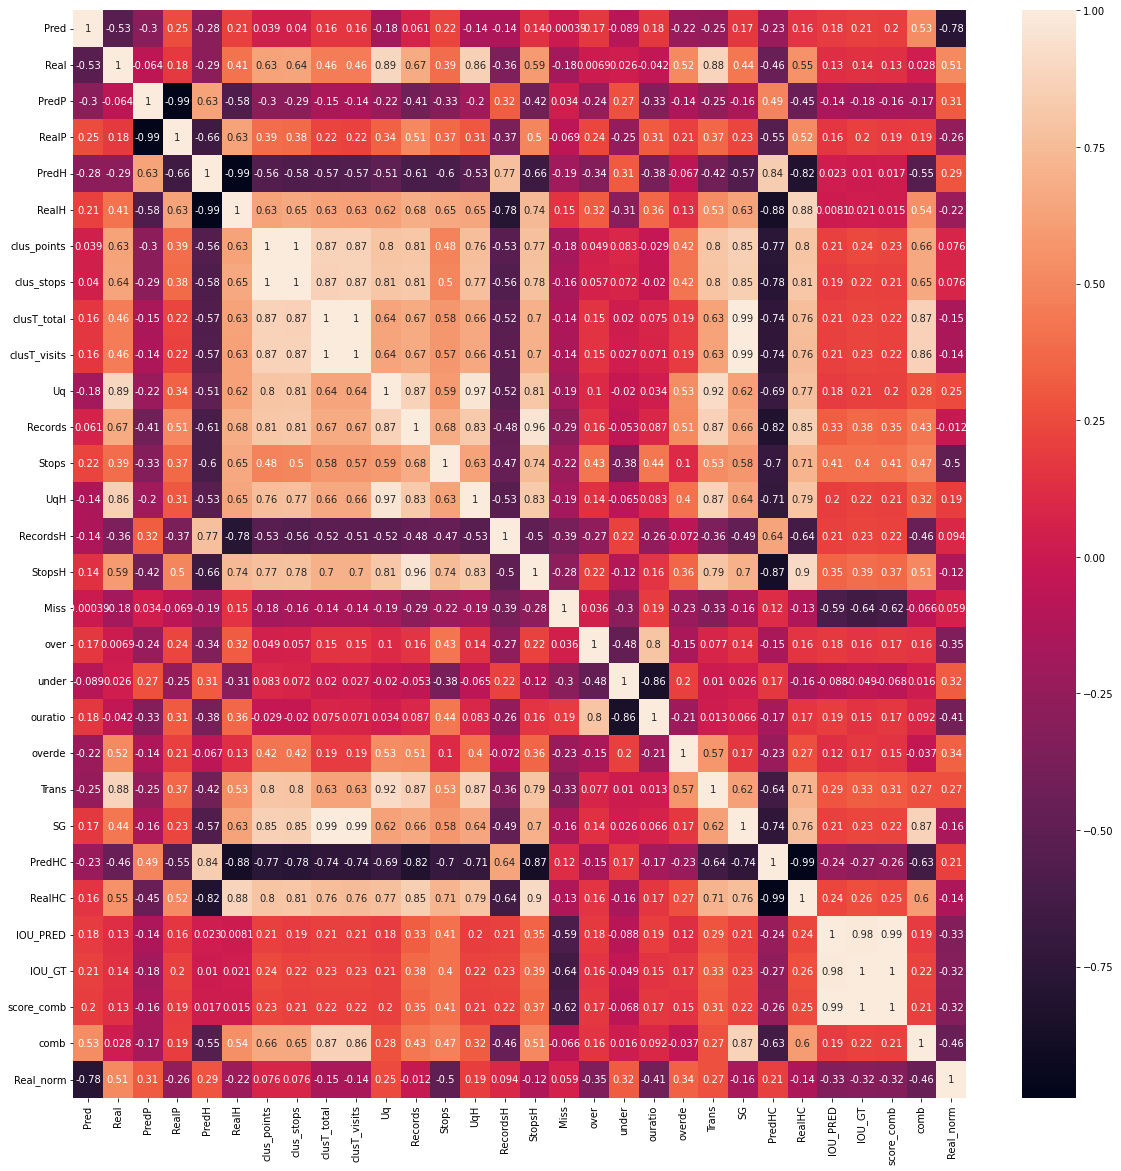

In [37]:
plt.figure(figsize=(20,20))
sns.heatmap(joined.corr('spearman'),annot=True)

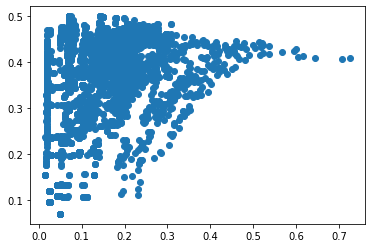

In [38]:
plt.scatter(joined['RealP'],joined['score_comb'])

In [11]:
xs = [x.loc[0].Pred for x in results.values()]
ys = [x.loc[0].clusT for x in results.values()]

AttributeError: 'Series' object has no attribute 'clusT'

In [ ]:
[x.columns for x in results.values()][0]

In [5]:
import plotly.graph_objects as go
import numpy as np
import plotly.io as pio
pio.renderers.default = 'notebook'

xval = 'PredH_30T'
yval = 'RealH_30T'
def draw_frontier_plotly(person):
    # Example data (replace these with your actual values)
    x_values = [x.loc[person][xval] for x in results.values()]
    y_values = [x.loc[person][yval] for x in results.values()]
    z_values = [(2*x.loc[person]['IOU_GT']*x.loc[person]['IOU_PRED'])/(x.loc[person]['IOU_GT']+x.loc[person]['IOU_PRED']) for x in results.values()]
#     z_values [x.loc[person]]['IOU_GT'] for x in results.values()]
    s_values = [x.loc[person]['Stops']/2 for x in results.values()]
    s_values = list(pd.Series(s_values).fillna(1))
    
    annot = []
#     for x in results.values():
#         row = x.loc[person]
#         text = (
#             f"clus_points: {row['clus_points']:.3f}<br>"
#             f"clusT_total: {row['clusT_total']:.3f}<br>"
#             f"clusT_visits: {row['clusT_visits']:.3f}<br>"
#             f"clus_stops: {row['clus_stops']:.3f}<br>"
#             f"RealP: {row['RealP']:.2f}<br>"
#             f"RealH: {row['RealH']:.2f}<br>"
#             f"Uq: {row['Uq']}<br>"
#             f"Records: {row['Records']}<br>"
#             f"Stops: {row['Stops']}<br>"
#             f"Trans: {row['Trans']:.2f}<br>"
#             f"Miss: {row['Miss']:.2f}, Over: {row['over']:.2f}, Under: {row['under']:.2f}"
#         )
#         annot.append(text)


    # Combine the values into a single array
    data = np.array(list(zip(x_values, y_values)))

    # Sort by x first, then by y (descending for both maximization)
    data = data[np.lexsort((data[:, 1], -data[:, 0]))]

    # Find Pareto frontier (Maximizing both x and y)
    pareto_frontier = []
    for point in data:
        if not pareto_frontier or point[1] > pareto_frontier[-1][1]:  # Keep if y is better
            pareto_frontier.append(point)

    pareto_frontier = np.array(pareto_frontier)

    # Extract Pareto frontier points
    frontier_x = pareto_frontier[:, 0]
    frontier_y = pareto_frontier[:, 1]

    # Create the Plotly figure
    fig = go.Figure()
    

    # Scatter plot of all points
    fig.add_trace(go.Scatter(
        x=x_values, 
        y=y_values,
        mode='markers',
        marker=dict(size=s_values, color=z_values, colorscale='Viridis', showscale=True),
        name='All Points',
        text=annot,  # Add annotations as text
        hovertemplate=(
            '<b>X:</b> %{x}<br>'
            '<b>Y:</b> %{y}<br>'
            '<b>Z:</b> %{marker.color}<br>'
            '<b>Annotation:</b> %{text}<extra></extra>'
        )
    ))

#     Line plot for the Pareto frontier
#     fig.add_trace(go.Scatter(
#         x=frontier_x,
#         y=frontier_y,
#         mode='lines+markers',
#         line=dict(color='rgba(255,0,0,0.5)', width=2),
#         marker=dict(size=10, symbol='circle'),
#         name='Pareto Frontier',
#         hovertemplate='<b>X:</b> %{x}<br><b>Y:</b> %{y}<extra></extra>'
#     ))

    # Add layout details
    fig.update_layout(
        title="Pareto Frontier (Maximizing Both X and Y)",
        xaxis_title=xval,
        yaxis_title=yval,
        legend=dict(font_size=12),
        template="plotly_white"
    )

    # Show the plot
    print(person)
    fig.show()
#     plt.savefig(r"D:\GitHub\OptimalStop\plots\raw\{}.png".format(person))


In [6]:
[draw_frontier_plotly(x) for x in [0,1,2,3,4,6,7,8,9,11,12,13,14,15,16,17,18,19]]

0


1


2


3


4


...

16


17


18


19


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

0


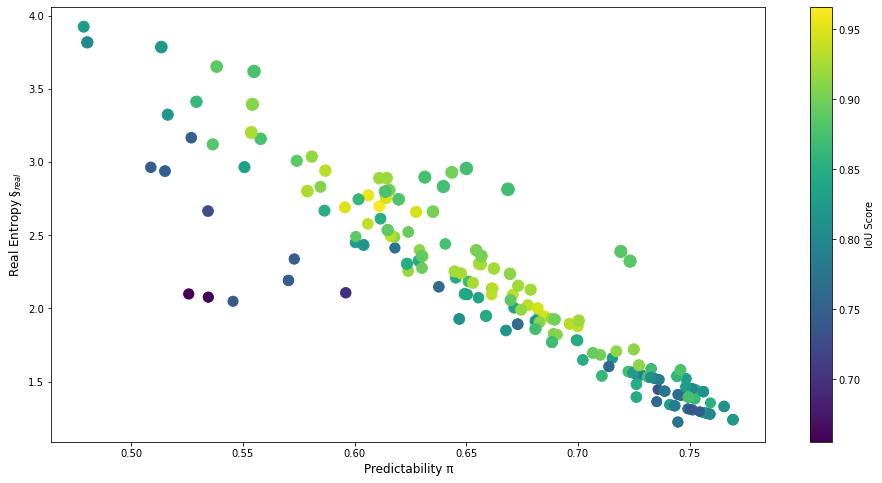

1


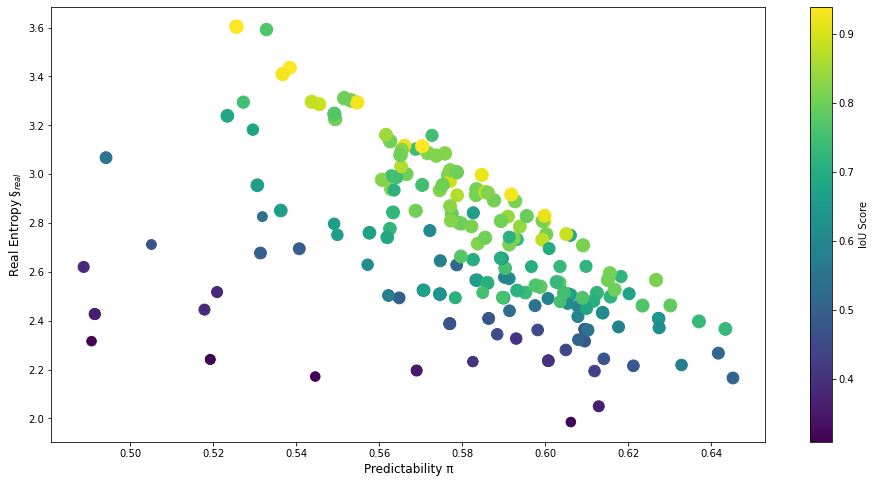

2


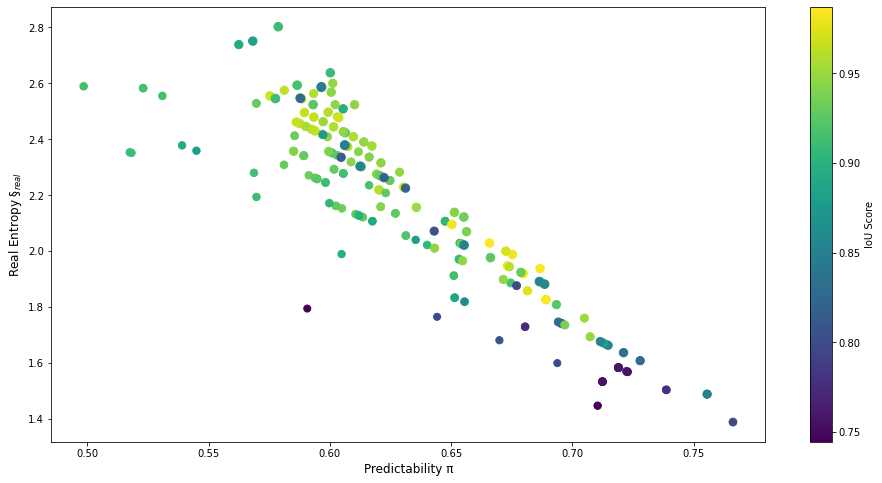

3


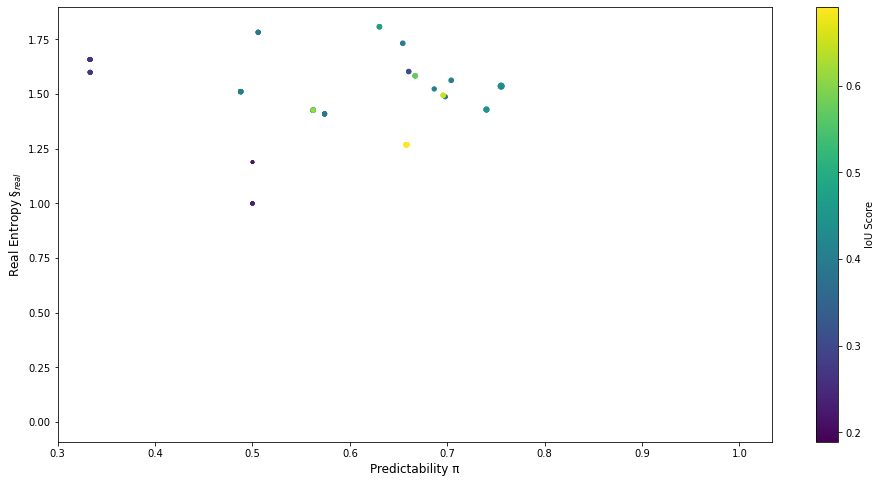

4


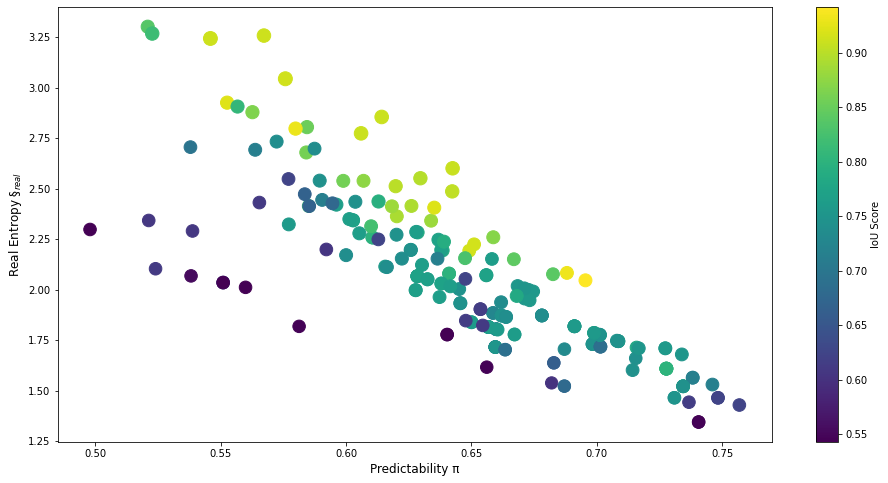

6


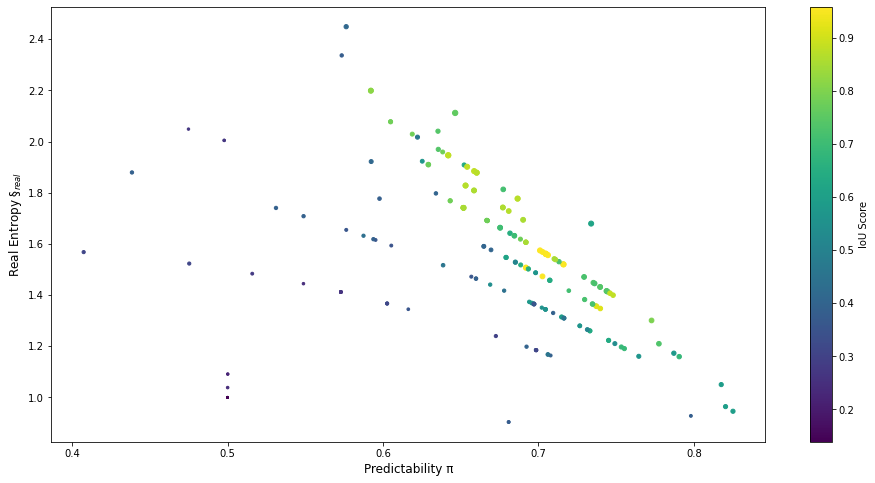

7


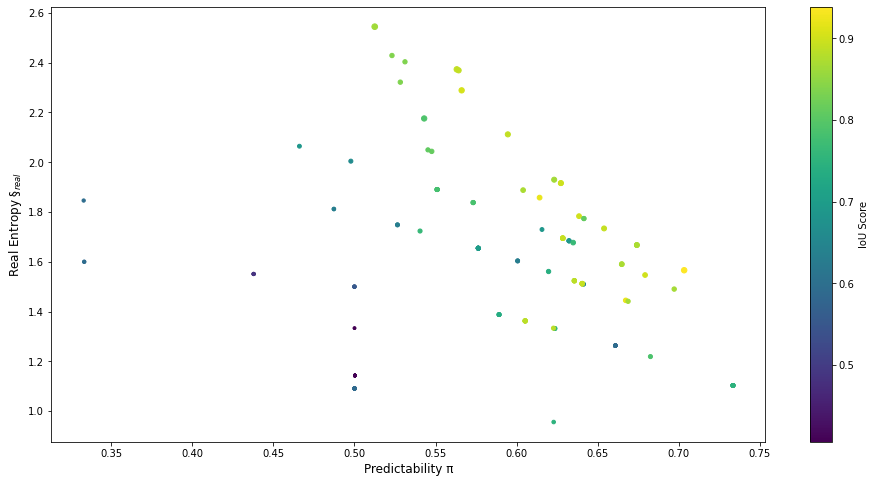

8


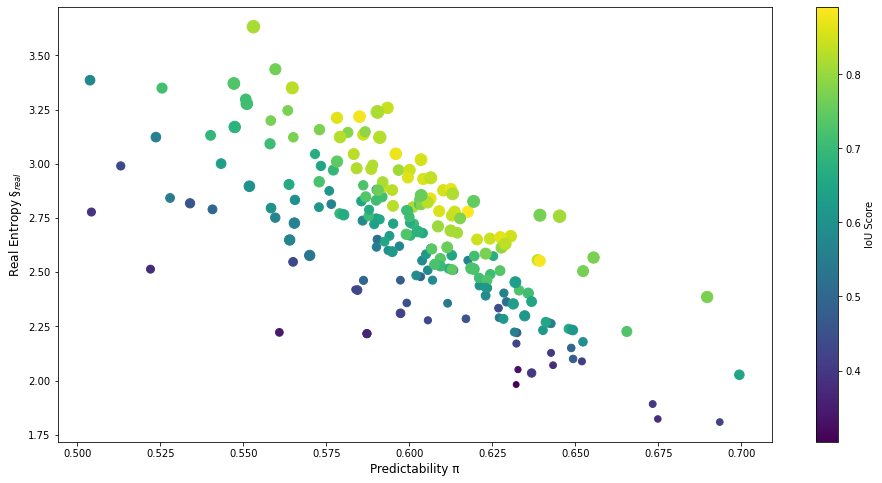

9


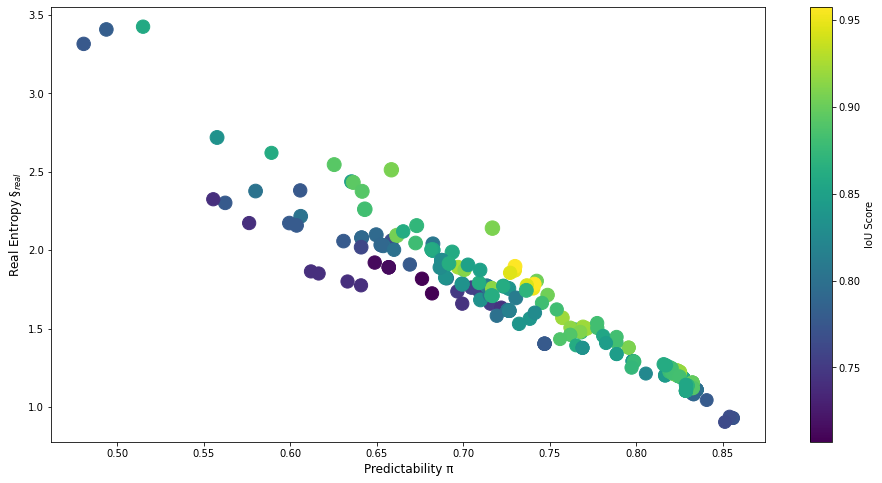

11


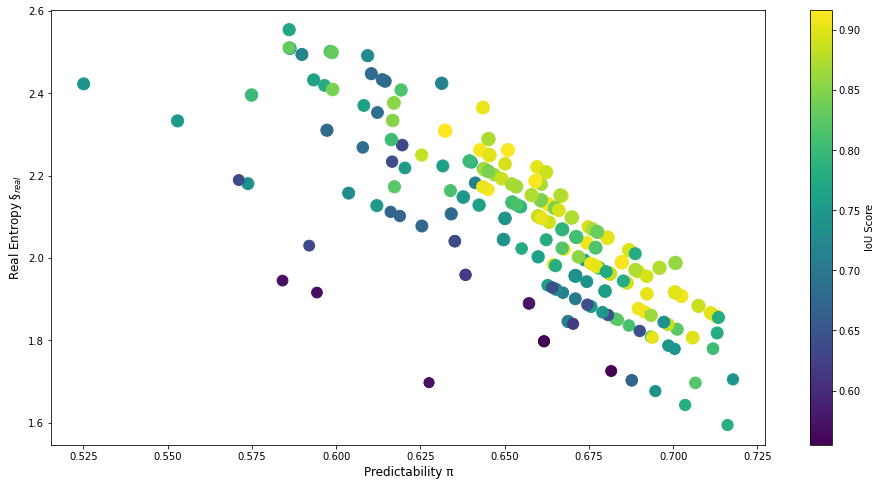

12


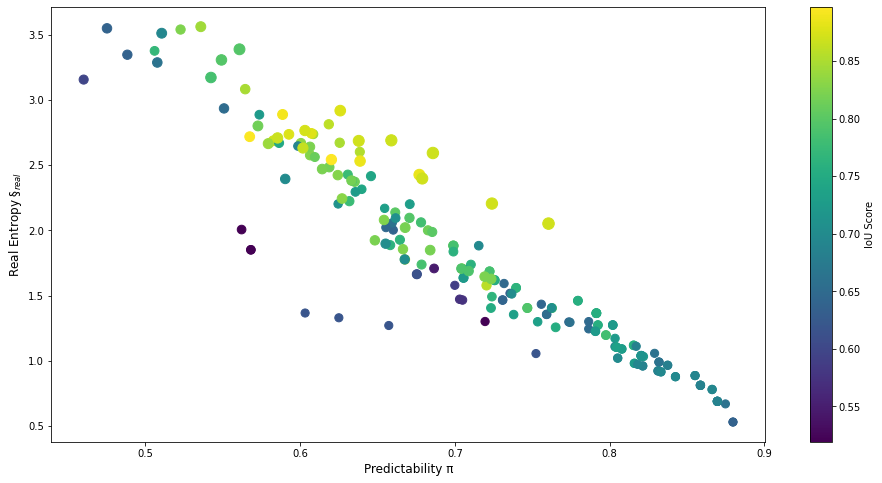

13


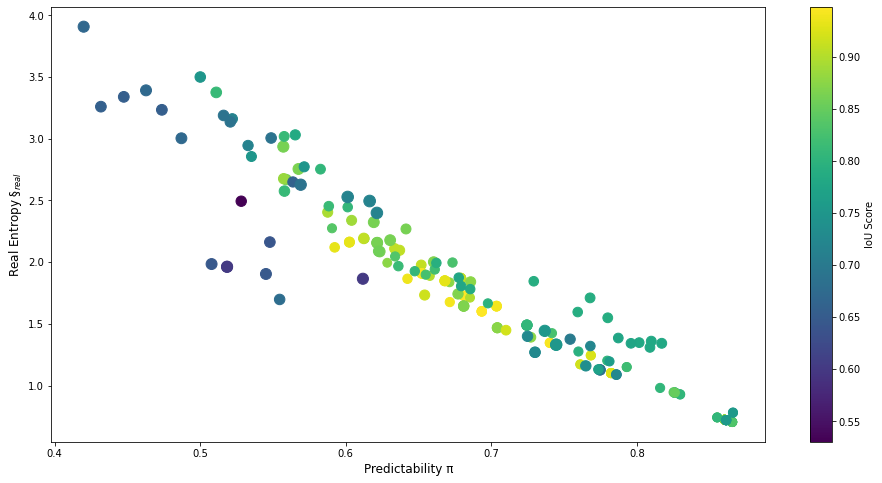

14


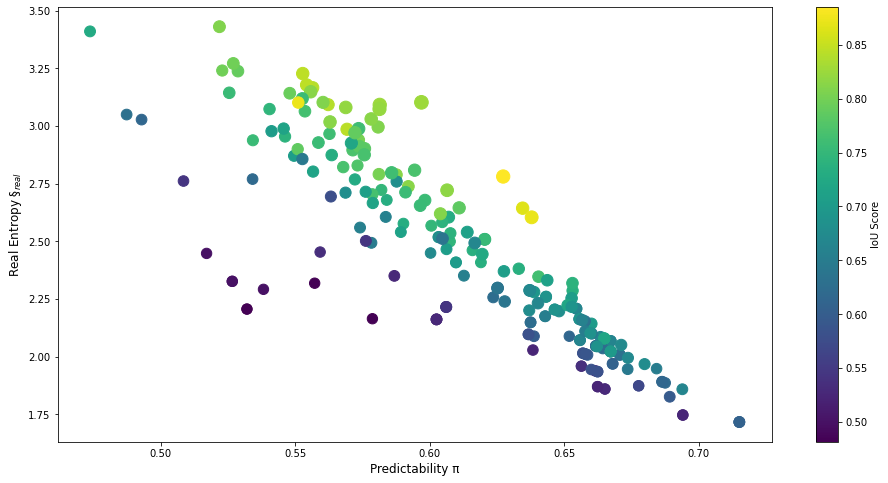

15


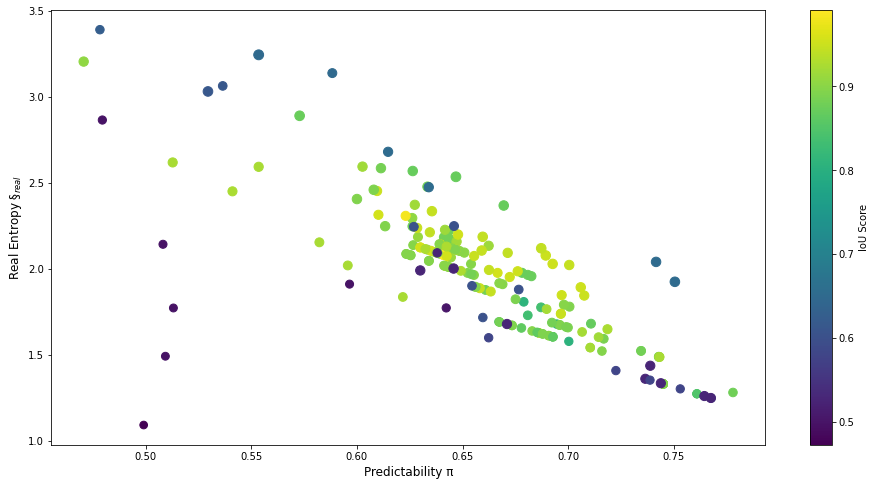

16


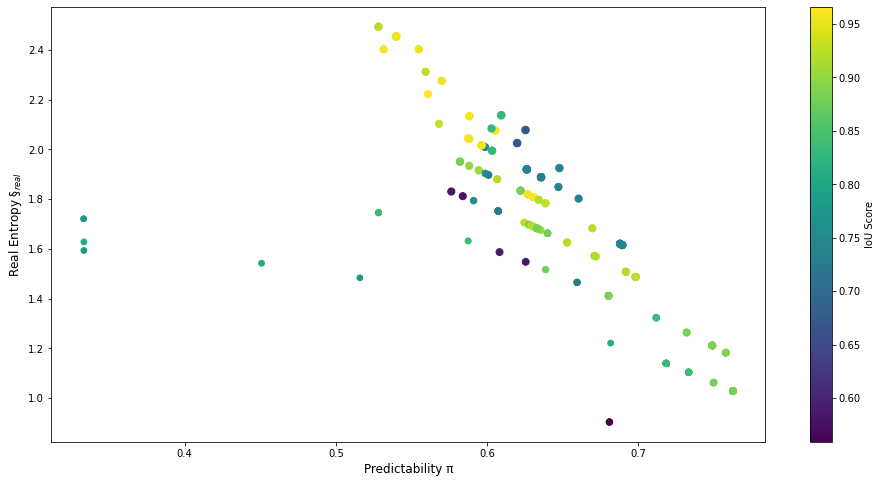

17


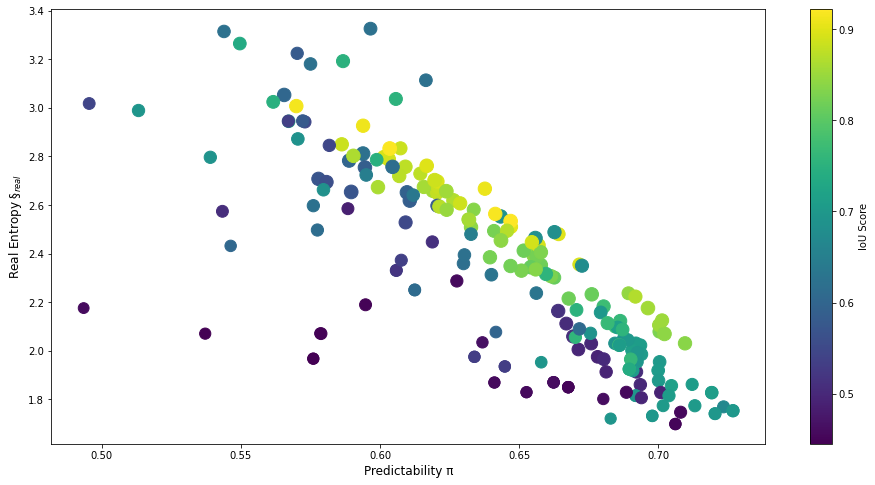

18


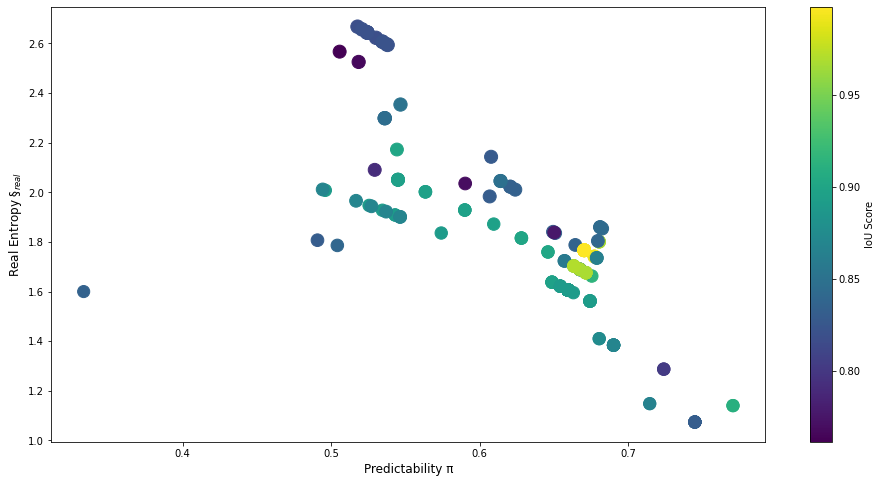

19


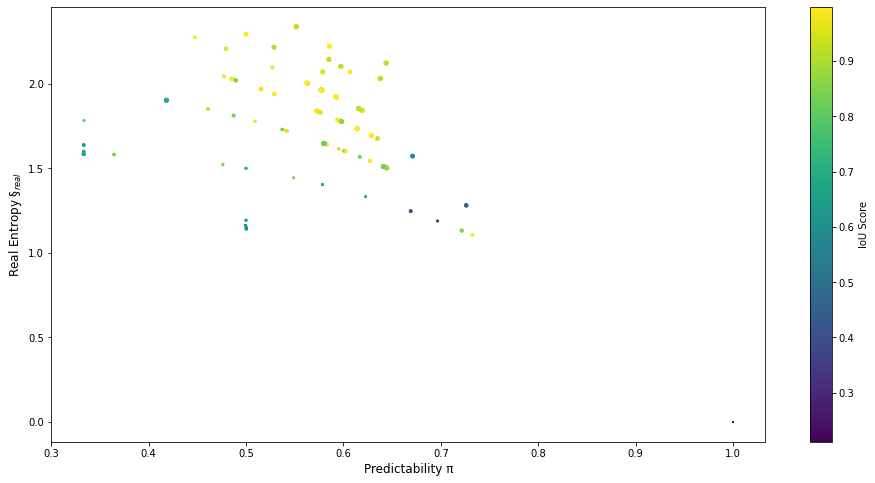

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [34]:
import plotly.graph_objects as go
import numpy as np
import plotly.io as pio
pio.renderers.default = 'notebook'

xval = 'Pred'
yval = 'Real'
def draw_frontier_plotly(person):
    # Example data (replace these with your actual values)
    x_values = [x.loc[person][xval] for x in results.values()]
    y_values = [x.loc[person][yval] for x in results.values()]
    z_values = [(2*x.loc[person]['IOU_GT']*x.loc[person]['IOU_PRED'])/(x.loc[person]['IOU_GT']+x.loc[person]['IOU_PRED']) for x in results.values()]
#     z_values [x.loc[person]]['IOU_GT'] for x in results.values()]
    s_values = [x.loc[person]['clusT_total']*1000 for x in results.values()]
    annot = [x for x in results.keys()]  # Annotations for each point

    # Combine the values into a single array
    data = np.array(list(zip(x_values, y_values)))

    # Sort by x first, then by y (descending for both maximization)
    data = data[np.lexsort((data[:, 1], -data[:, 0]))]

    # Find Pareto frontier (Maximizing both x and y)
    pareto_frontier = []
    for point in data:
        if not pareto_frontier or point[1] > pareto_frontier[-1][1]:  # Keep if y is better
            pareto_frontier.append(point)

    pareto_frontier = np.array(pareto_frontier)

    # Extract Pareto frontier points
    frontier_x = pareto_frontier[:, 0]
    frontier_y = pareto_frontier[:, 1]
    

    # Scatter plot of all points
    plt.figure(figsize=(16,8))
    plt.scatter(x_values,y_values,c=z_values,s=s_values)
    
#     Line plot for the Pareto frontier
#     fig.add_trace(go.Scatter(
#         x=frontier_x,
#         y=frontier_y,
#         mode='lines+markers',
#         line=dict(color='red', width=2),
#         marker=dict(size=10, symbol='circle'),
#         name='Pareto Frontier',
#         hovertemplate='<b>X:</b> %{x}<br><b>Y:</b> %{y}<extra></extra>'
#     ))

    # Add layout details
    # Show the plot
    print(person)
    plt.savefig(r"D:\GitHub\OptimalStop\plots\norm\n{}.png".format(person), format='png')
    cbar = plt.colorbar()
    cbar.ax.set_ylabel("IoU Score")
    plt.xlabel("Predictability π", size = 12)
    plt.ylabel(r"Real Entropy $\S_{real}$", size=12)
    plt.show()
        
[draw_frontier_plotly(x) for x in [0,1,2,3,4,6,7,8,9,11,12,13,14,15,16,17,18,19]]

In [12]:
import matplotlib.pyplot as plt
import numpy as np

xval = 'PredH_30T'
yval = 'RealH_30T'

def draw_frontier_plotly(person):
    # Example data (replace these with your actual values)
    x_values = [x.loc[person][xval] for x in results.values()]
    y_values = [x.loc[person][yval] for x in results.values()]
    z_values = [(2 * x.loc[person]['IOU_GT'] * x.loc[person]['IOU_PRED']) / (x.loc[person]['IOU_GT'] + x.loc[person]['IOU_PRED']) for x in results.values()]
    s_values = [x.loc[person]['clusT_total'] * 1000 for x in results.values()]
    annot = [x for x in results.keys()]  # Annotations for each point

    # Combine the values into a single array
    data = np.array(list(zip(x_values, y_values)))

    # Sort by x first, then by y (descending for both maximization)
    data = data[np.lexsort((data[:, 1], -data[:, 0]))]

    # Find Pareto frontier (Maximizing both x and y)
    pareto_frontier = []
    for point in data:
        if not pareto_frontier or point[1] > pareto_frontier[-1][1]:  # Keep if y is better
            pareto_frontier.append(point)

    pareto_frontier = np.array(pareto_frontier)
    frontier_x = pareto_frontier[:, 0]
    frontier_y = pareto_frontier[:, 1]

    # Scatter plot of all points
    plt.figure(figsize=(16, 8))
    scatter = plt.scatter(x_values, y_values, c=z_values, s=s_values, cmap='viridis')

    # Plot Pareto frontier line
    plt.plot(frontier_x, frontier_y, color='red', linewidth=2, alpha=0.8, label='Pareto Frontier')

    # Add colorbar
    cbar = plt.colorbar(scatter)
    cbar.ax.set_ylabel("IoU Score")

    # Add labels and legend
    plt.xlabel("Predictability π", size=12)
    plt.ylabel(r"Real Entropy $S_{real}$", size=12)
    plt.legend()
    plt.title(f"Pareto Front for Person {person}")

    # Save to file
    save_path = r"D:\GitHub\OptimalStop\plots\norm\n{}.png".format(person)
    plt.savefig(save_path, format='png', facecolor='white')
    print(f"Plot saved to {save_path}")

    plt.close()

# Example batch run
[draw_frontier_plotly(x) for x in [0, 1, 2, 3, 4, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19]]


Plot saved to D:\GitHub\OptimalStop\plots\norm\n0.png
Plot saved to D:\GitHub\OptimalStop\plots\norm\n1.png
Plot saved to D:\GitHub\OptimalStop\plots\norm\n2.png
Plot saved to D:\GitHub\OptimalStop\plots\norm\n3.png
Plot saved to D:\GitHub\OptimalStop\plots\norm\n4.png
Plot saved to D:\GitHub\OptimalStop\plots\norm\n6.png
Plot saved to D:\GitHub\OptimalStop\plots\norm\n7.png
Plot saved to D:\GitHub\OptimalStop\plots\norm\n8.png
Plot saved to D:\GitHub\OptimalStop\plots\norm\n9.png
Plot saved to D:\GitHub\OptimalStop\plots\norm\n11.png
Plot saved to D:\GitHub\OptimalStop\plots\norm\n12.png
Plot saved to D:\GitHub\OptimalStop\plots\norm\n13.png
Plot saved to D:\GitHub\OptimalStop\plots\norm\n14.png
Plot saved to D:\GitHub\OptimalStop\plots\norm\n15.png
Plot saved to D:\GitHub\OptimalStop\plots\norm\n16.png
Plot saved to D:\GitHub\OptimalStop\plots\norm\n17.png
Plot saved to D:\GitHub\OptimalStop\plots\norm\n18.png
Plot saved to D:\GitHub\OptimalStop\plots\norm\n19.png


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [22]:
import plotly.graph_objects as go
import numpy as np
import plotly.io as pio
pio.renderers.default = 'notebook'

xval = 'RealP'
yval = 'Stops'
def draw_frontier_plotly(person):
    # Example data (replace these with your actual values)
    x_values = [x.loc[person][xval] for x in results.values()]
    y_values = [x.loc[person][yval] for x in results.values()]
    z_values = [(2*x.loc[person]['IOU_GT']*x.loc[person]['IOU_PRED'])/(x.loc[person]['IOU_GT']+x.loc[person]['IOU_PRED']) for x in results.values()]
    annot = [x for x in results.keys()]  # Annotations for each point

    # Combine the values into a single array
    data = np.array(list(zip(x_values, y_values)))

    # Sort by x first, then by y (descending for both maximization)
    data = data[np.lexsort((data[:, 1], -data[:, 0]))]

    # Find Pareto frontier (Maximizing both x and y)
    pareto_frontier = []
    for point in data:
        if not pareto_frontier or point[1] > pareto_frontier[-1][1]:  # Keep if y is better
            pareto_frontier.append(point)

    pareto_frontier = np.array(pareto_frontier)

    # Extract Pareto frontier points
    frontier_x = pareto_frontier[:, 0]
    frontier_y = pareto_frontier[:, 1]

    # Create the Plotly figure
    fig = go.Figure()
    

    # Scatter plot of all points
    fig.add_trace(go.Scatter(
        x=x_values, 
        y=y_values,
        mode='markers',
        marker=dict(size=8, color=z_values, colorscale='Viridis', showscale=True),
        name='All Points',
        text=annot,  # Add annotations as text
        hovertemplate=(
            '<b>X:</b> %{x}<br>'
            '<b>Y:</b> %{y}<br>'
            '<b>Z:</b> %{marker.color}<br>'
            '<b>Annotation:</b> %{text}<extra></extra>'
        )
    ))

#     Line plot for the Pareto frontier
    fig.add_trace(go.Scatter(
        x=frontier_x,
        y=frontier_y,
        mode='lines+markers',
        line=dict(color='red', width=2),
        marker=dict(size=10, symbol='circle'),
        name='Pareto Frontier',
        hovertemplate='<b>X:</b> %{x}<br><b>Y:</b> %{y}<extra></extra>'
    ))

    # Add layout details
    fig.update_layout(
        title="Pareto Frontier (Maximizing Both X and Y)",
        xaxis_title=xval,
        yaxis_title=yval,
        legend=dict(font_size=12),
        template="plotly_white"
    )

    # Show the plot
    fig.show()


In [23]:
[draw_frontier_plotly(x) for x in [0,1,2,3,4,6,7,8]]

KeyError: 'RealP'

In [40]:
import plotly.graph_objects as go
import numpy as np

xval = "Pred"
yval = "Real"
size_max_px = 26          # max pixel diameter for biggest bubble
size_min_px = 6           # min pixel diameter for smallest bubble

def draw_frontier_plotly(person):
    # --- gather the series we need -----------------------------------------
    x_values  = [tbl.loc[person][xval]  for tbl in results.values()]
    y_values  = [tbl.loc[person][yval]  for tbl in results.values()]
    stops_raw = [tbl.loc[person]["Stops"]      for tbl in results.values()]
    z_values  = [
        (2*tbl.loc[person]["IOU_GT"]*tbl.loc[person]["IOU_PRED"])
        /(tbl.loc[person]["IOU_GT"]+tbl.loc[person]["IOU_PRED"])
        for tbl in results.values()
    ]
    annot = list(results.keys())

    # --- scale Stops → pixel sizes  ----------------------------------------
    s_min, s_max = min(stops_raw), max(stops_raw)
    rng = (s_max - s_min) or 1          # protect against divide-by-zero
    sizes = [
        size_min_px + (size_max_px-size_min_px)*(s - s_min)/rng
        for s in stops_raw
    ]

    # --- compute Pareto frontier (unchanged) -------------------------------
    data = np.array(list(zip(x_values, y_values)))
    data = data[np.lexsort((data[:, 1], -data[:, 0]))]   # sort by x desc, y asc
    pareto = []
    for pt in data:
        if not pareto or pt[1] > pareto[-1][1]:
            pareto.append(pt)
    pareto = np.array(pareto)
    front_x, front_y = pareto[:, 0], pareto[:, 1]

    # --- build the figure ---------------------------------------------------
    fig = go.Figure()

    # Scatter of all points
    fig.add_trace(go.Scatter(
        x=x_values,
        y=y_values,
        mode="markers",
        marker=dict(
            size=sizes,
            sizemode="diameter",
            sizeref=1,               # Plotly handles absolute pixel sizes here
            color=z_values,
            colorscale="Viridis",
            showscale=True,
            colorbar=dict(title="Custom<br>Score")
        ),
        text=annot,
        hovertemplate=(
            "<b>X:</b> %{x}<br>"
            "<b>Y:</b> %{y}<br>"
            "<b>Stops:</b> %{marker.size:.0f}<br>"
            "<b>Score:</b> %{marker.color:.3f}<br>"
            "<b>Run:</b> %{text}<extra></extra>"
        ),
        name="All Points"
    ))

#     (Optional) draw Pareto frontier as a line
    # fig.add_trace(go.Scatter(
    #     x=front_x, y=front_y,
    #     mode="lines+markers",
    #     line=dict(width=2, dash="dash", color="red"),
    #     marker=dict(size=10),
    #     name="Pareto Frontier"
    # ))

    fig.update_layout(
        title=f"Pareto Frontier – bubble size ∝ Stops  ({person})",
        xaxis_title=xval,
        yaxis_title=yval,
        template="plotly_white",
        legend_font_size=12
    )

    fig.show()


In [41]:
[draw_frontier_plotly(x) for x in [0,1,2,3,4,6,7,8]]

ValueError: 
    Invalid element(s) received for the 'size' property of scatter.marker
        Invalid elements include: [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

    The 'size' property is a number and may be specified as:
      - An int or float in the interval [0, inf]
      - A tuple, list, or one-dimensional numpy array of the above